# Daily Sentiment Scoring for Stock News

This notebook processes news articles for stocks and computes average daily sentiment scores when multiple articles are published on the same day.

In [11]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Load and Prepare Data

In [12]:
# Sample data structure - replace with your actual data loading
# Expected columns: date, stock_symbol, headline, content, sentiment_score (optional)

# Example of loading from CSV
# df = pd.read_csv('stock_news.csv')

# For demonstration, let's create sample data
sample_data = {
    'date': [
        '2024-01-15', '2024-01-15', '2024-01-15',  # Multiple articles same day
        '2024-01-16', '2024-01-16',
        '2024-01-17', '2024-01-17', '2024-01-17', '2024-01-17',  # 4 articles same day
        '2024-01-18',
        '2024-01-15', '2024-01-16', '2024-01-17'  # Different stock
    ],
    'stock_symbol': [
        'NVDA', 'NVDA', 'NVDA',
        'NVDA', 'NVDA',
        'NVDA', 'NVDA', 'NVDA', 'NVDA',
        'NVDA',
        'AAPL', 'AAPL', 'AAPL'
    ],
    'headline': [
        'NVIDIA reports strong earnings',
        'NVIDIA AI chips gain market share', 
        'Analysts upgrade NVIDIA price target',
        'NVIDIA faces supply chain concerns',
        'NVIDIA announces new GPU release',
        'NVIDIA stock hits new high',
        'NVIDIA partners with major tech company',
        'NVIDIA AI research breakthrough',
        'NVIDIA earnings exceed expectations',
        'NVIDIA dividend announcement',
        'Apple releases new iPhone',
        'Apple faces regulatory scrutiny',
        'Apple AI features announced'
    ],
    'content': [
        'NVIDIA reported better than expected quarterly earnings...',
        'NVIDIAs AI chips are gaining significant market share...',
        'Several analysts have upgraded their price targets for NVIDIA...',
        'NVIDIA is facing some supply chain challenges...',
        'NVIDIA announced their latest GPU technology...',
        'NVIDIA stock reached an all-time high today...',
        'NVIDIA announced a strategic partnership...',
        'NVIDIA research team made breakthrough in AI...',
        'NVIDIA earnings once again beat expectations...',
        'NVIDIA announced quarterly dividend increase...',
        'Apple unveiled their latest iPhone model...',
        'Apple is facing increased regulatory scrutiny...',
        'Apple announced new AI features for their products...'
    ]
}

df = pd.DataFrame(sample_data)
df['date'] = pd.to_datetime(df['date'])

print("Sample data shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData info:")
print(df.info())

Sample data shape: (13, 4)

First few rows:
        date stock_symbol                              headline  \
0 2024-01-15         NVDA        NVIDIA reports strong earnings   
1 2024-01-15         NVDA     NVIDIA AI chips gain market share   
2 2024-01-15         NVDA  Analysts upgrade NVIDIA price target   
3 2024-01-16         NVDA    NVIDIA faces supply chain concerns   
4 2024-01-16         NVDA      NVIDIA announces new GPU release   

                                             content  
0  NVIDIA reported better than expected quarterly...  
1  NVIDIAs AI chips are gaining significant marke...  
2  Several analysts have upgraded their price tar...  
3   NVIDIA is facing some supply chain challenges...  
4    NVIDIA announced their latest GPU technology...  

Data info:
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1

## Sentiment Analysis

In [13]:
def calculate_sentiment(text):
    """
    Calculate sentiment score using TextBlob
    Returns polarity between -1 (negative) and 1 (positive)
    """
    if pd.isna(text) or text == '':
        return 0.0
    
    # Combine headline and content for more comprehensive analysis
    blob = TextBlob(str(text))
    return blob.sentiment.polarity

# Calculate sentiment for each article
df['sentiment_score'] = df.apply(lambda row: calculate_sentiment(row['headline'] + ' ' + row['content']), axis=1)

print("Sentiment scores calculated:")
print(df[['date', 'stock_symbol', 'headline', 'sentiment_score']].head(10))

Sentiment scores calculated:
        date stock_symbol                                 headline  \
0 2024-01-15         NVDA           NVIDIA reports strong earnings   
1 2024-01-15         NVDA        NVIDIA AI chips gain market share   
2 2024-01-15         NVDA     Analysts upgrade NVIDIA price target   
3 2024-01-16         NVDA       NVIDIA faces supply chain concerns   
4 2024-01-16         NVDA         NVIDIA announces new GPU release   
5 2024-01-17         NVDA               NVIDIA stock hits new high   
6 2024-01-17         NVDA  NVIDIA partners with major tech company   
7 2024-01-17         NVDA          NVIDIA AI research breakthrough   
8 2024-01-17         NVDA      NVIDIA earnings exceed expectations   
9 2024-01-18         NVDA             NVIDIA dividend announcement   

   sentiment_score  
0         0.277778  
1         0.375000  
2         0.000000  
3         0.000000  
4         0.318182  
5         0.152121  
6         0.062500  
7         0.000000  
8         0

## Compute Daily Average Sentiment Scores

In [14]:
def compute_daily_average_sentiment(df):
    """
    Compute average daily sentiment scores for each stock
    When multiple articles exist for the same stock on the same day,
    calculate the average sentiment score
    """
    
    # Group by date and stock symbol, then calculate mean sentiment
    daily_sentiment = df.groupby(['date', 'stock_symbol']).agg({
        'sentiment_score': ['mean', 'count', 'std'],
        'headline': 'count'
    }).round(4)
    
    # Flatten column names
    daily_sentiment.columns = ['avg_sentiment', 'article_count', 'sentiment_std', 'headline_count']
    daily_sentiment = daily_sentiment.reset_index()
    
    # Add sentiment category
    daily_sentiment['sentiment_category'] = pd.cut(
        daily_sentiment['avg_sentiment'],
        bins=[-1, -0.1, 0.1, 1],
        labels=['Negative', 'Neutral', 'Positive']
    )
    
    return daily_sentiment

# Calculate daily average sentiment
daily_sentiment_df = compute_daily_average_sentiment(df)

print("Daily Average Sentiment Scores:")
print(daily_sentiment_df)

print("\nSummary statistics:")
print(daily_sentiment_df.groupby('stock_symbol')['avg_sentiment'].describe())

Daily Average Sentiment Scores:
        date stock_symbol  avg_sentiment  article_count  sentiment_std  \
0 2024-01-15         AAPL         0.3182              1            NaN   
1 2024-01-15         NVDA         0.2176              3         0.1946   
2 2024-01-16         AAPL         0.0000              1            NaN   
3 2024-01-16         NVDA         0.1591              2         0.2250   
4 2024-01-17         AAPL         0.1364              1            NaN   
5 2024-01-17         NVDA         0.0537              4         0.0720   
6 2024-01-18         NVDA         0.0000              1            NaN   

   headline_count sentiment_category  
0               1           Positive  
1               3           Positive  
2               1            Neutral  
3               2           Positive  
4               1           Positive  
5               4            Neutral  
6               1            Neutral  

Summary statistics:
              count      mean       std  m

## Analyze Multiple Articles per Day

In [15]:
# Show days with multiple articles for the same stock
multiple_articles = daily_sentiment_df[daily_sentiment_df['article_count'] > 1]

print("Days with multiple articles for the same stock:")
print(multiple_articles[['date', 'stock_symbol', 'article_count', 'avg_sentiment', 'sentiment_category']])

# Show original articles for a specific day to demonstrate averaging
example_date = '2024-01-15'
example_stock = 'NVDA'

print(f"\nOriginal articles for {example_stock} on {example_date}:")
original_articles = df[(df['date'] == example_date) & (df['stock_symbol'] == example_stock)]
for idx, row in original_articles.iterrows():
    print(f"- {row['headline']}: {row['sentiment_score']:.3f}")

avg_sentiment = original_articles['sentiment_score'].mean()
print(f"\nAverage sentiment for {example_stock} on {example_date}: {avg_sentiment:.3f}")

Days with multiple articles for the same stock:
        date stock_symbol  article_count  avg_sentiment sentiment_category
1 2024-01-15         NVDA              3         0.2176           Positive
3 2024-01-16         NVDA              2         0.1591           Positive
5 2024-01-17         NVDA              4         0.0537            Neutral

Original articles for NVDA on 2024-01-15:
- NVIDIA reports strong earnings: 0.278
- NVIDIA AI chips gain market share: 0.375
- Analysts upgrade NVIDIA price target: 0.000

Average sentiment for NVDA on 2024-01-15: 0.218


## Visualization

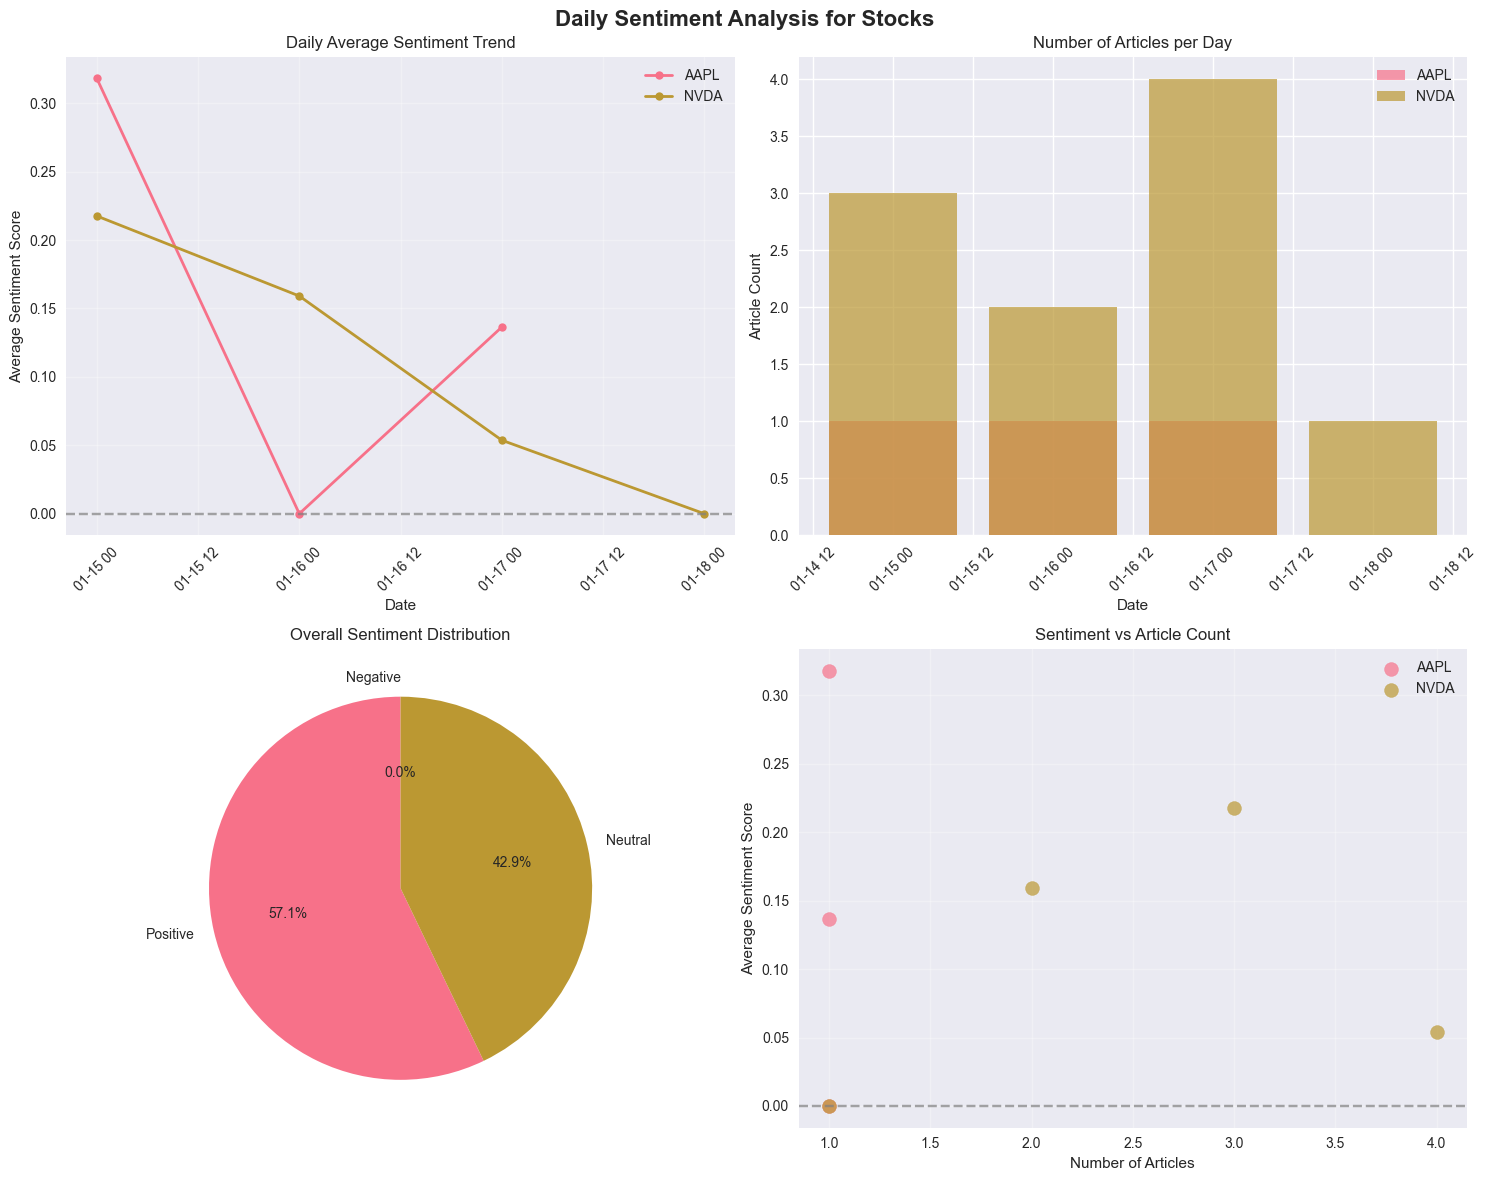

In [16]:
# Create visualization for daily sentiment trends
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Daily Sentiment Analysis for Stocks', fontsize=16, fontweight='bold')

# 1. Daily sentiment trend line plot
for stock in daily_sentiment_df['stock_symbol'].unique():
    stock_data = daily_sentiment_df[daily_sentiment_df['stock_symbol'] == stock]
    axes[0, 0].plot(stock_data['date'], stock_data['avg_sentiment'], 
                   marker='o', label=stock, linewidth=2, markersize=6)

axes[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Daily Average Sentiment Trend')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Average Sentiment Score')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Article count per day
for stock in daily_sentiment_df['stock_symbol'].unique():
    stock_data = daily_sentiment_df[daily_sentiment_df['stock_symbol'] == stock]
    axes[0, 1].bar(stock_data['date'], stock_data['article_count'], 
                   alpha=0.7, label=stock, width=0.8)

axes[0, 1].set_title('Number of Articles per Day')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Article Count')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Sentiment distribution
sentiment_counts = daily_sentiment_df['sentiment_category'].value_counts()
axes[1, 0].pie(sentiment_counts.values, labels=sentiment_counts.index, 
               autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Overall Sentiment Distribution')

# 4. Sentiment vs Article Count scatter
for stock in daily_sentiment_df['stock_symbol'].unique():
    stock_data = daily_sentiment_df[daily_sentiment_df['stock_symbol'] == stock]
    axes[1, 1].scatter(stock_data['article_count'], stock_data['avg_sentiment'], 
                      s=100, alpha=0.7, label=stock)

axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title('Sentiment vs Article Count')
axes[1, 1].set_xlabel('Number of Articles')
axes[1, 1].set_ylabel('Average Sentiment Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Export Results

In [17]:
# Export daily sentiment scores to CSV
output_filename = 'daily_sentiment_scores.csv'
daily_sentiment_df.to_csv(output_filename, index=False)
print(f"Daily sentiment scores exported to {output_filename}")

# Create summary statistics
summary_stats = daily_sentiment_df.groupby('stock_symbol').agg({
    'avg_sentiment': ['mean', 'std', 'min', 'max'],
    'article_count': ['sum', 'mean'],
    'sentiment_category': lambda x: x.mode().iloc[0] if not x.mode().empty else 'N/A'
}).round(4)

summary_stats.columns = ['Mean Sentiment', 'Sentiment Std', 'Min Sentiment', 
                         'Max Sentiment', 'Total Articles', 'Avg Articles/Day', 
                         'Most Common Category']

print("\nSummary Statistics by Stock:")
print(summary_stats)

# Export summary stats
summary_stats.to_csv('sentiment_summary_stats.csv')
print("\nSummary statistics exported to sentiment_summary_stats.csv")

Daily sentiment scores exported to daily_sentiment_scores.csv

Summary Statistics by Stock:
              Mean Sentiment  Sentiment Std  Min Sentiment  Max Sentiment  \
stock_symbol                                                                
AAPL                  0.1515         0.1596            0.0         0.3182   
NVDA                  0.1076         0.0987            0.0         0.2176   

              Total Articles  Avg Articles/Day Most Common Category  
stock_symbol                                                         
AAPL                       3               1.0             Positive  
NVDA                      10               2.5              Neutral  

Summary statistics exported to sentiment_summary_stats.csv


## Key Functions for Reuse

In [18]:
def process_stock_news_sentiment(input_data, date_col='date', stock_col='stock_symbol', 
                                headline_col='headline', content_col='content'):
    """
    Main function to process stock news and compute daily average sentiment scores
    
    Parameters:
    - input_data: DataFrame or path to CSV file
    - date_col: name of date column
    - stock_col: name of stock symbol column
    - headline_col: name of headline column
    - content_col: name of content column
    
    Returns:
    - DataFrame with daily average sentiment scores
    """
    
    # Load data if path provided
    if isinstance(input_data, str):
        df = pd.read_csv(input_data)
    else:
        df = input_data.copy()
    
    # Convert date column
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Calculate sentiment for each article
    df['sentiment_score'] = df.apply(
        lambda row: calculate_sentiment(row[headline_col] + ' ' + row[content_col]), 
        axis=1
    )
    
    # Compute daily averages
    daily_sentiment = df.groupby([date_col, stock_col]).agg({
        'sentiment_score': ['mean', 'count', 'std']
    }).round(4)
    
    daily_sentiment.columns = ['avg_sentiment', 'article_count', 'sentiment_std']
    daily_sentiment = daily_sentiment.reset_index()
    
    # Add sentiment category
    daily_sentiment['sentiment_category'] = pd.cut(
        daily_sentiment['avg_sentiment'],
        bins=[-1, -0.1, 0.1, 1],
        labels=['Negative', 'Neutral', 'Positive']
    )
    
    return daily_sentiment

print("Key functions defined. Use process_stock_news_sentiment() to process your own data.")

Key functions defined. Use process_stock_news_sentiment() to process your own data.
